# Day 44 — K-Means from Scratch

In notebook 01 scikit-learn did everything for us. Here we open the box: we write K-Means ourselves
(see [`kmeans.py`](kmeans.py)) and **watch each iteration**.

**What you will learn**
1. The two-step loop: **assign → update** (theory §4)
2. Verify the hand-worked example from theory §5
3. Watch centroids move on the student data
4. See a **local minimum** caused by bad initialisation, and how restarts fix it (theory §6)
5. Confirm our implementation matches scikit-learn

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from kmeans import KMeans          # our own implementation

## Step 1 — The building blocks, one at a time

Before using the class, let's write each step as plain NumPy on the 6-point example from **theory §5**.

In [2]:
P = np.array([[2, 3], [3, 3], [6, 8], [7, 8], [3, 4], [8, 7]], dtype=float)
names = ['A', 'B', 'C', 'D', 'E', 'F']

# Step 1: initialise - deliberately bad start: A and B (both in the same real group)
centroids = P[[0, 1]].copy()
centroids

array([[2., 3.],
       [3., 3.]])

**Assign step**: distance from every point to every centroid, then pick the nearest.

Broadcasting trick: `P[:, None, :]` has shape (6, 1, 2) and `centroids[None, :, :]` has shape (1, 2, 2).
Their difference has shape (6, 2, 2), and taking the norm over the last axis gives a **(6 points × 2 centroids)** distance table.

In [3]:
distances = np.linalg.norm(P[:, None, :] - centroids[None, :, :], axis=2)
labels = distances.argmin(axis=1)

pd.DataFrame(distances.round(2), index=names, columns=['dist to μ1', 'dist to μ2']).assign(cluster=labels + 1)

,dist to μ1,dist to μ2,cluster
A,0.00,1.00,1
B,1.00,0.00,2
C,6.40,5.83,2
D,7.07,6.40,2
E,1.41,1.00,2
F,7.21,6.40,2


These are exactly the numbers in the *Iteration 1* table of theory §5. Now the **update step**: each centroid becomes the mean of its points.

In [4]:
centroids = np.array([P[labels == k].mean(axis=0) for k in range(2)])
centroids

array([[2. , 3. ],
       [5.4, 6. ]])

μ₁ = (2, 3) and μ₂ = (5.4, 6.0), as computed by hand. Now loop until nothing moves, printing **WCSS** every time:

In [5]:
centroids = P[[0, 1]].copy()

for it in range(1, 10):
    labels = np.linalg.norm(P[:, None] - centroids[None], axis=2).argmin(axis=1)
    wcss = ((P - centroids[labels]) ** 2).sum()
    groups = [''.join(np.array(names)[labels == k]) for k in range(2)]
    print(f"iter {it}: clusters {groups}, WCSS before update = {wcss:.2f}")

    new_centroids = np.array([P[labels == k].mean(axis=0) for k in range(2)])
    if np.allclose(new_centroids, centroids):
        print("centroids did not move -> converged")
        break
    centroids = new_centroids

print("final centroids:\n", centroids.round(2))

iter 1: clusters ['A', 'BCDEF'], WCSS before update = 117.00
iter 2: clusters ['ABE', 'CDF'], WCSS before update = 21.68
iter 3: clusters ['ABE', 'CDF'], WCSS before update = 4.00
centroids did not move -> converged
final centroids:
 [[2.67 3.33]
 [7.   7.67]]


WCSS goes 117 → 21.68 → 4.0 and **never increases**; this is why K-Means is guaranteed to converge (theory §4).
Even from a bad start, this simple example reached the correct groups {A, B, E} and {C, D, F}.

## Step 2 — Use our `KMeans` class on the student data

`kmeans.py` wraps the same steps in a class with an sklearn-like API: `fit_predict`, `predict`,
`labels_`, `inertia_`, `n_iter_`. It also stores the centroids of every iteration in `history_` so we can draw them.

In [6]:
df = pd.read_csv('student_clustering.csv')
X = df[['cgpa', 'iq']].values

km = KMeans(n_clusters=4, max_iter=500, random_state=3)
y_means = km.fit_predict(X)

print("Converged in", km.n_iter_, "iterations")
print("Inertia (WCSS):", round(km.inertia_, 2))

Converged in 4 iterations
Inertia (WCSS): 681.97


### Watch the centroids move
Each panel shows the cluster assignments at that iteration; ✕ marks the centroids.

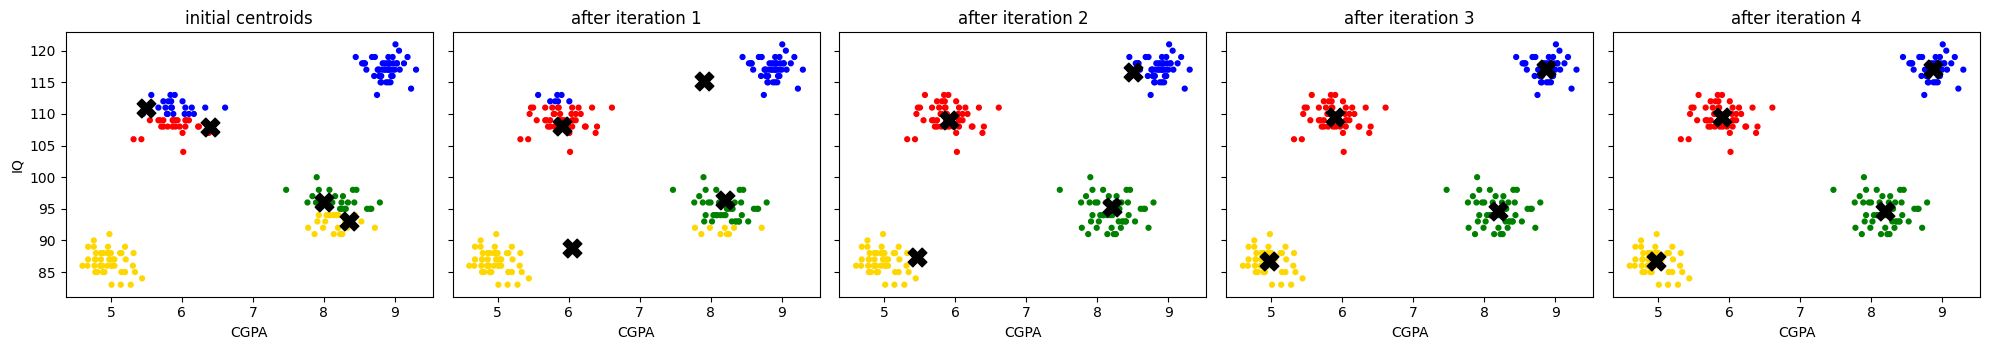

In [7]:
colors = np.array(['red', 'blue', 'green', 'gold'])
steps = km.history_
fig, axes = plt.subplots(1, len(steps), figsize=(4 * len(steps), 3.6), sharey=True)

for ax, (i, C) in zip(axes, enumerate(steps)):
    lab = np.linalg.norm(X[:, None] - C[None], axis=2).argmin(axis=1)
    ax.scatter(X[:, 0], X[:, 1], c=colors[lab], s=12)
    ax.scatter(C[:, 0], C[:, 1], c='black', marker='X', s=180)
    ax.set_title('initial centroids' if i == 0 else f'after iteration {i}')
    ax.set_xlabel('CGPA')
axes[0].set_ylabel('IQ')
plt.tight_layout()
plt.show()

The centroids start at random students and slide toward the centres of the 4 groups within a few iterations. Once they stop moving, the algorithm stops.

## Step 3 — Local minima: why initialisation matters (theory §6)

K-Means only ever goes *downhill*, so a bad starting point can trap it. Let's run our implementation
(plain random initialisation, a **single** start) with 10 different seeds:

In [8]:
results = []
for seed in range(10):
    m = KMeans(n_clusters=4, random_state=seed)
    m.fit_predict(X)
    results.append({'seed': seed, 'inertia': round(m.inertia_, 2), 'iterations': m.n_iter_})

pd.DataFrame(results)

,seed,inertia,iterations
0,0,2280.22,3
1,1,2264.79,3
2,2,2271.58,4
3,3,681.97,4
4,4,2271.58,3
5,5,681.97,4
6,6,2354.09,3
7,7,2435.09,4
8,8,2263.49,3
9,9,681.97,4


Only some seeds reach the best inertia (≈ **682**); many stop at ≈ 2270 or worse. Let's look at a bad run:

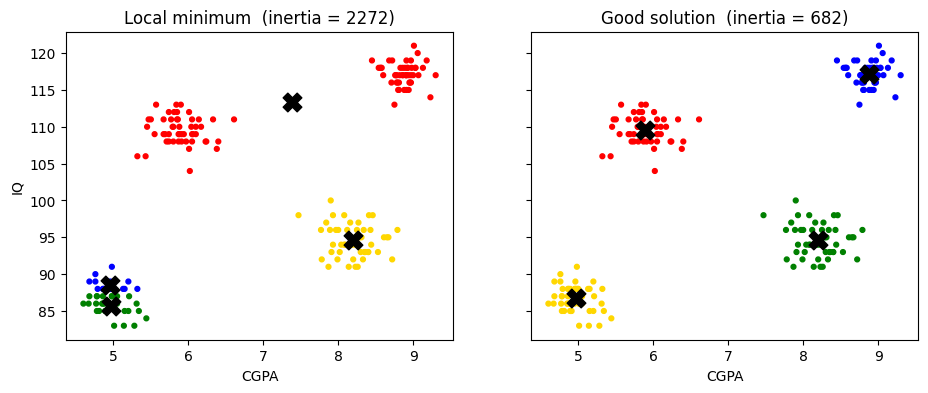

In [9]:
bad = KMeans(n_clusters=4, random_state=2)
good = KMeans(n_clusters=4, random_state=3)
lab_bad, lab_good = bad.fit_predict(X), good.fit_predict(X)

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, m, lab, title in [(axes[0], bad, lab_bad, 'Local minimum'), (axes[1], good, lab_good, 'Good solution')]:
    ax.scatter(X[:, 0], X[:, 1], c=colors[lab], s=12)
    ax.scatter(m.centroids[:, 0], m.centroids[:, 1], c='black', marker='X', s=180)
    ax.set_title(f'{title}  (inertia = {m.inertia_:.0f})')
    ax.set_xlabel('CGPA')
axes[0].set_ylabel('IQ')
plt.show()

In the bad run, two centroids share one real group and one centroid covers two real groups. The algorithm has
**converged** (nothing moves), but to the wrong answer.

**Fix 1: restarts.** Run several times and keep the lowest inertia. This is exactly what sklearn's `n_init` does:

In [10]:
def kmeans_best_of(X, k, n_init=10):
    best = None
    for seed in range(n_init):
        m = KMeans(n_clusters=k, random_state=seed)
        m.fit_predict(X)
        if best is None or m.inertia_ < best.inertia_:
            best = m
    return best

best = kmeans_best_of(X, 4, n_init=10)
print("Best inertia over 10 restarts:", round(best.inertia_, 2))

Best inertia over 10 restarts: 681.97


**Fix 2: k-means++.** Choose starting centroids that are spread out (sklearn's default `init='k-means++'`).
Together with restarts it makes bad runs very rare.

## Step 4 — Compare with scikit-learn

In [11]:
from sklearn.cluster import KMeans as SklearnKMeans
from sklearn.metrics import adjusted_rand_score

sk = SklearnKMeans(n_clusters=4, n_init=10, random_state=42).fit(X)

print("Our inertia     :", round(best.inertia_, 2))
print("sklearn inertia :", round(sk.inertia_, 2))
print("Adjusted Rand Index between the two labelings:", adjusted_rand_score(best.labels_, sk.labels_))

Our inertia     : 681.97
sklearn inertia : 681.97
Adjusted Rand Index between the two labelings: 1.0


Same inertia, and an **Adjusted Rand Index of 1.0**, so the two groupings are identical
(ARI ignores the label numbers, which may differ). Our 60-line implementation reproduces scikit-learn.

---
## Key takeaways
- K-Means = repeat **(assign each point to its nearest centroid) → (move each centroid to the mean)**.
- WCSS never increases, so it always converges, but possibly to a **local minimum**.
- Restarts (`n_init`) + smart initialisation (**k-means++**) fix this in practice.
- Vectorised NumPy (broadcasting + `argmin`) computes all distances in one line.